In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look professional
plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
# Load from your data/processed folder, skipping any rows with rogue commas
nav_df = pd.read_csv('../data/processed/clean_nav_history.csv', on_bad_lines='skip')
tx_df = pd.read_csv('../data/processed/clean_transactions.csv', on_bad_lines='skip')

print("Data loaded successfully from data/processed!")

Data loaded successfully from data/processed!


In [5]:
# Check your columns first if the error persists
# print(nav_df.columns) 

# UPDATE 'daily_return_pct' below to match the actual column name found in your print() output
column_name = 'daily_return_pct' 

def calculate_risk_metrics(group):
    var_95 = group.quantile(0.05)
    cvar_95 = group[group < var_95].mean()
    return pd.Series({'VaR_95': var_95, 'CVaR_95': cvar_95})

# Ensure the column exists
if column_name in nav_df.columns:
    risk_report = nav_df.groupby('scheme_name')[column_name].apply(calculate_risk_metrics).unstack()
    risk_report.to_csv('../reports/var_cvar_report.csv')
    print("VaR & CVaR report saved successfully!")
    display(risk_report.head())
else:
    print(f"Error: Column '{column_name}' not found. Available columns are: {nav_df.columns.tolist()}")

Error: Column 'daily_return_pct' not found. Available columns are: ['amfi_code', 'nav_date', 'nav']


In [7]:
print("--- COLUMN NAMES IN NAV HISTORY ---")
print(nav_df.columns.tolist())

print("\n--- COLUMN NAMES IN TRANSACTIONS ---")
print(tx_df.columns.tolist())

--- COLUMN NAMES IN NAV HISTORY ---
['amfi_code', 'nav_date', 'nav']

--- COLUMN NAMES IN TRANSACTIONS ---
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [8]:
# 1. Calculate daily returns from the NAV price
nav_df = nav_df.sort_values(['amfi_code', 'nav_date'])
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

# 2. Load the fund master to get the actual names
fund_master = pd.read_csv('../data/processed/clean_fund_master.csv')

# 3. Merge fund names into your nav data
nav_df = nav_df.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

# 4. Now calculate VaR/CVaR using 'scheme_name' and 'daily_return'
def calculate_risk_metrics(group):
    var_95 = group.quantile(0.05)
    cvar_95 = group[group < var_95].mean()
    return pd.Series({'VaR_95': var_95, 'CVaR_95': cvar_95})

risk_report = nav_df.groupby('scheme_name')['daily_return'].apply(calculate_risk_metrics).unstack()
risk_report.to_csv('../reports/var_cvar_report.csv')

print("VaR/CVaR report saved!")
display(risk_report.head())

VaR/CVaR report saved!


,VaR_95,CVaR_95
scheme_name,,
ABSL Frontline Equity Fund - Regular - Growth,-0.012173,-0.016075
ABSL Liquid Fund - Regular - Growth,-0.000218,-0.000371
ABSL Small Cap Fund - Regular - Growth,-0.023915,-0.030289
Axis Bluechip Fund - Direct - Growth,-0.012588,-0.016332
Axis Bluechip Fund - Regular - Growth,-0.012693,-0.016166


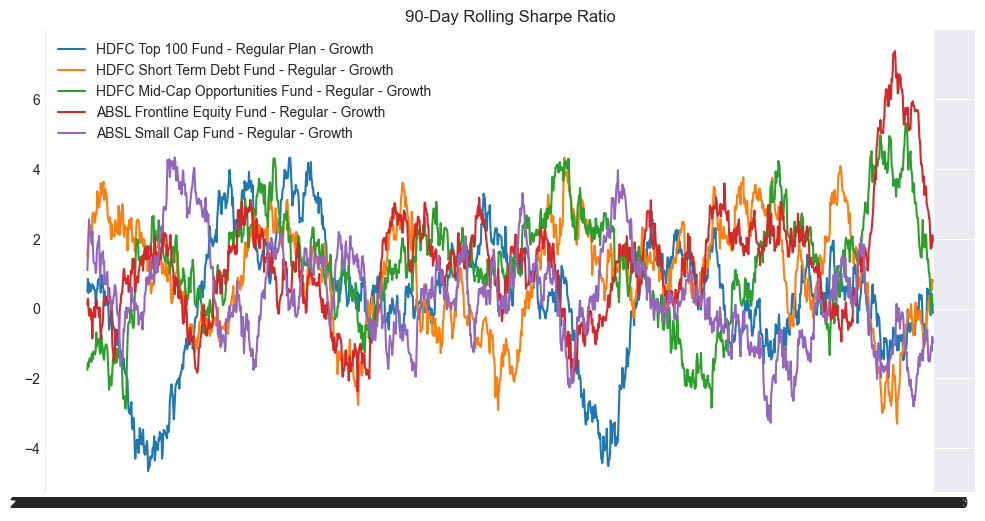

In [9]:
# Select first 5 funds
key_funds = nav_df['scheme_name'].dropna().unique()[:5]

plt.figure(figsize=(12, 6))
for fund in key_funds:
    fund_data = nav_df[nav_df['scheme_name'] == fund].copy()
    # Rolling 90-day calculation
    rolling_mean = fund_data['daily_return'].rolling(window=90).mean()
    rolling_std = fund_data['daily_return'].rolling(window=90).std()
    fund_data['rolling_sharpe'] = (rolling_mean / rolling_std) * np.sqrt(252)
    plt.plot(fund_data['nav_date'], fund_data['rolling_sharpe'], label=fund)

plt.title('90-Day Rolling Sharpe Ratio')
plt.legend()
plt.savefig('../png/rolling_sharpe_chart.png')
plt.show()

In [10]:
# 1. Prepare Data
nav_df = pd.read_csv('../data/processed/clean_nav_history.csv')
fund_master = pd.read_csv('../data/processed/clean_fund_master.csv')

# 2. Calculate daily returns (Percentage change of NAV)
nav_df = nav_df.sort_values(['amfi_code', 'nav_date'])
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

# 3. Add Scheme Names
nav_df = nav_df.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

# 4. VaR / CVaR Calculation
def calculate_risk_metrics(group):
    # Dropping NaNs created by pct_change()
    returns = group.dropna()
    var_95 = returns.quantile(0.05)
    cvar_95 = returns[returns < var_95].mean()
    return pd.Series({'VaR_95': var_95, 'CVaR_95': cvar_95})

risk_report = nav_df.groupby('scheme_name')['daily_return'].apply(calculate_risk_metrics).unstack()

# 5. Export
risk_report.to_csv('../reports/var_cvar_report.csv')
print("VaR/CVaR report saved to reports/var_cvar_report.csv!")
display(risk_report.head())

VaR/CVaR report saved to reports/var_cvar_report.csv!


,VaR_95,CVaR_95
scheme_name,,
ABSL Frontline Equity Fund - Regular - Growth,-0.012173,-0.016075
ABSL Liquid Fund - Regular - Growth,-0.000218,-0.000371
ABSL Small Cap Fund - Regular - Growth,-0.023915,-0.030289
Axis Bluechip Fund - Direct - Growth,-0.012588,-0.016332
Axis Bluechip Fund - Regular - Growth,-0.012693,-0.016166


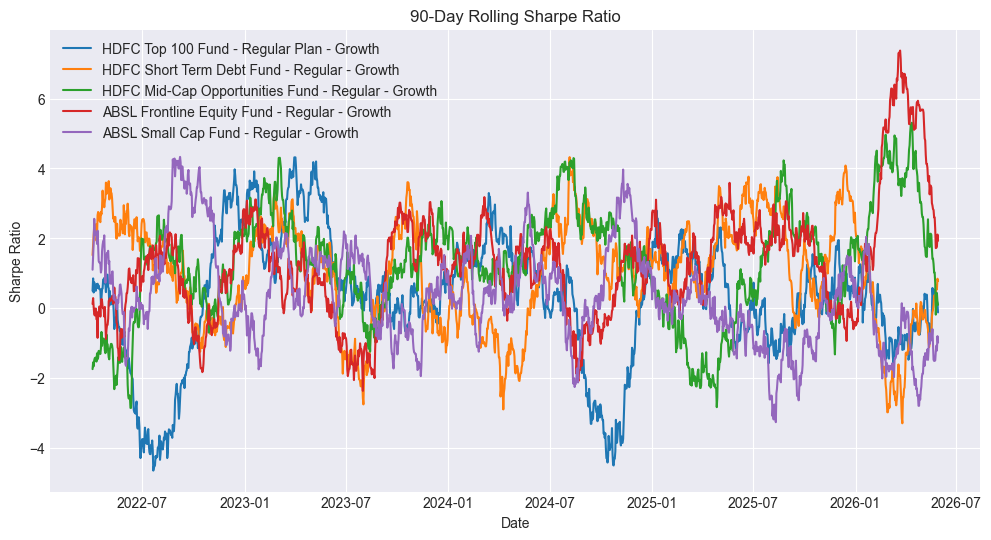

In [11]:
# 1. Filter to 5 funds
top_funds = nav_df['scheme_name'].dropna().unique()[:5]

# 2. Plotting
plt.figure(figsize=(12, 6))
for fund in top_funds:
    fund_data = nav_df[nav_df['scheme_name'] == fund].copy()
    fund_data['nav_date'] = pd.to_datetime(fund_data['nav_date'])
    fund_data = fund_data.sort_values('nav_date')
    
    # Rolling 90-day Sharpe
    rolling_mean = fund_data['daily_return'].rolling(window=90).mean()
    rolling_std = fund_data['daily_return'].rolling(window=90).std()
    fund_data['rolling_sharpe'] = (rolling_mean / rolling_std) * np.sqrt(252)
    
    plt.plot(fund_data['nav_date'], fund_data['rolling_sharpe'], label=fund)

plt.title('90-Day Rolling Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.savefig('../png/rolling_sharpe_chart.png')
plt.show()